# Introduction

This notebook starts by giving an introduction in the data of Porto Seguro competition. Then follows with preparing and running few predictive models using cross-validation and stacking and prepares a submission.

The notebook is using elements from the following kernels:

* [Data Preparation and Exploration](https://www.kaggle.com/code/bertcarremans/data-preparation-exploration) by Bert Carremans.
* [Steering Wheel of Fortune - Porto Seguro EDA](https://www.kaggle.com/code/headsortails/steering-wheel-of-fortune-porto-seguro-eda) by Heads or Tails
* [Interactive Porto Insights - A Plot.ly Tutorial](https://www.kaggle.com/code/arthurtok/interactive-porto-insights-a-plot-ly-tutorial) by Anisotropic
* [Simple Stacker](https://www.kaggle.com/code/yekenot/simple-stacker-lb-0-284) by Vladimir Demidov


# Analysis packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', 100)

# Load the data

In [2]:
trainset = pd.read_csv('./input/train.csv')
testset = pd.read_csv('./input/test.csv')

# Few quick observations

We can make few observations based on the data description in the competition:

* Few **groups** are defined and features that belongs to these groups include patterns in the name (ind, reg, car, calc). The **ind** indicates most probably **individual**, **reg** is probably **registration**, **car** is self-explanatory, **calc** is a **calculated** field;
* The postfix **bin** is used for binary features;
* The postfix **cat** to is used for categorical features;
* Features without the **bin** or **cat** indications are real numbers (continuous values) of integers (ordinal values);
* A missing value is indicated by **-1**;
* The value that is subject of prediction is in the **target** column. This one indicates whether or not a claim was filed for that insured person;
* **id** is a data input ordinal number.

Let's glimpse the data to see if these interpretations are confirmed.

In [3]:
trainset.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


Indeed, we can observe the **cat** values are **categorical**, integer values ranging from **0** to **n**, **bin** values are **binary** (either 0 or 1).

Let's see how many rows and columns are in the data.

In [4]:
print('Train dataset (rows, cols):', trainset.shape, '\nTest dataset (rows, cols):', testset.shape)

Train dataset (rows, cols): (595212, 59) 
Test dataset (rows, cols): (892816, 58)


These are *59* columns in the training dataset and only *58* in the testing dataset. Since from this dataset should have been extracted the **target**, this seems fine. Let's check the difference between the columns set in the two datasets, to make sure everything is fine.

In [5]:
print('Columns in train and not in test dataset:', set(trainset.columns) - set(testset.columns))

Columns in train and not in test dataset: {'target'}


# Introduction of metadata

To make easier the manipulation of data, we will associate few meta-information to the variables in the trainset. This will facilitate the selection of various types of features for analysis, inspection or modeling. We are using as well a **category** field for the car, ind, reg and calc types of features.

What metadata will be used:

* **use**: input, ID, target
* **type**: nominal, interval, ordinal, binary
* **preserve**: True or False
* **dataType**: int, float, char
* **category**: ind, reg, car, calc

In [6]:
data = []
for feature in trainset.columns:
    if feature == 'target':
        use = 'target'
    elif feature == 'id':
        use = 'id'
    else:
        use = 'input'
    
    if 'bin' in feature or feature == 'target':
        type = 'binary'
    elif 'cat' in feature or feature == 'id':
        type = 'categorical'
    elif trainset[feature].dtype == float or isinstance(trainset[feature].dtype, float):
        type = 'real'
    elif trainset[feature].dtype == int:
        type = 'integer'
    
    preserve = True
    if feature == 'id':
        preserve = False
    
    dtype = trainset[feature].dtype

    category = 'none'

    if 'ind' in feature:
        category = 'individual'
    elif 'reg' in feature:
        category = 'registration'
    elif 'car' in feature:
        category = 'car'
    elif 'calc' in feature:
        category = 'calculated'
    
    feature_dictionary = {
        'varname': feature,
        'use': use,
        'type': type,
        'preserve': preserve,
        'dtype': dtype,
        'category': category
    }
    data.append(feature_dictionary)

metadata = pd.DataFrame(data, columns=['varname', 'use', 'type', 'preserve', 'dtype', 'category'])
metadata.set_index('varname', inplace=True)
metadata

,use,type,preserve,dtype,category
varname,,,,,
id,id,categorical,False,int64,none
target,target,binary,True,int64,none
ps_ind_01,input,integer,True,int64,individual
ps_ind_02_cat,input,categorical,True,int64,individual
ps_ind_03,input,integer,True,int64,individual
ps_ind_04_cat,input,categorical,True,int64,individual
ps_ind_05_cat,input,categorical,True,int64,individual
ps_ind_06_bin,input,binary,True,int64,individual
ps_ind_07_bin,input,binary,True,int64,individual


We can extract, for example, all categorical values:

In [7]:
metadata[(metadata.type == 'categorical') & (metadata.preserve)].index

Index(['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat',
       'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat',
       'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat',
       'ps_car_10_cat', 'ps_car_11_cat'],
      dtype='object', name='varname')

Let's inspect all features, to see how many category distinct values do we have:

In [8]:
pd.DataFrame({'count': metadata.groupby(['category'])['category'].size()}).reset_index()

,category,count
0,calculated,20
1,car,16
2,individual,18
3,none,2
4,registration,3


We have 20 *calculated* features, 16 *car*, 18 *individual* and 3 *registration*.

Let's inspect now all features, to see how many use and type distinct values do we have:

In [9]:
pd.DataFrame({'count': metadata.groupby(['use', 'type'])['use'].size()}).reset_index()

,use,type,count
0,id,categorical,1
1,input,binary,17
2,input,categorical,14
3,input,integer,16
4,input,real,10
5,target,binary,1


There are one nominal feature (the **id**), 20 binary valeus, 21 real (or float numbers), 16 categorical features - all these being as well **input** values and one **target** value, which is as well **binary**, the **target**.

# Data analysis and statistics

## Target variable

<Figure size 640x480 with 0 Axes>

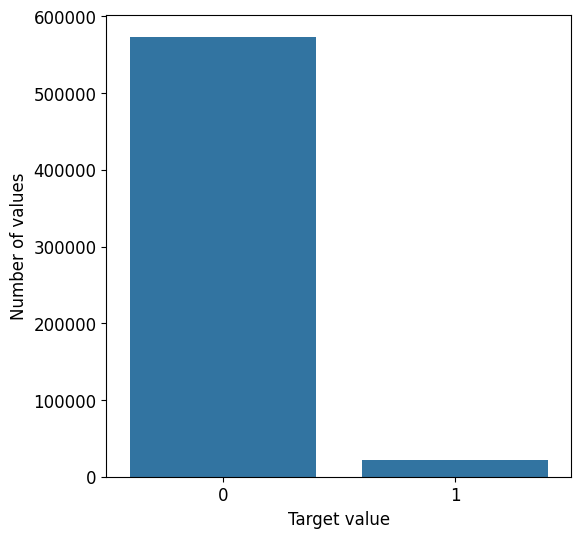

In [10]:
plt.figure()
fig, ax = plt.subplots(figsize=(6, 6))
x = trainset['target'].value_counts().index.values
y = trainset['target'].value_counts().values

sns.barplot(ax=ax, x=x, y=y)
plt.ylabel('Number of values', fontsize=12)
plt.xlabel('Target value', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

Only 3.64% of the target data have 1 value. This means that the training dataset is highly imbalanced. We can either undersample the records with target = 0 or oversample records with target = 1; because is a large dataset, we will do undersampling of records with target = 0.

## Real features

In [11]:
variable = metadata[(metadata.type == 'real') & (metadata.preserve)].index
trainset[variable].describe()

,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.610991,0.439184,0.551102,0.379945,0.813265,0.276256,3.065899,0.449756,0.449589,0.449849
std,0.287643,0.404264,0.793506,0.058327,0.224588,0.357154,0.731366,0.287198,0.286893,0.287153
min,0.000000,0.000000,-1.000000,-1.000000,0.250619,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.200000,0.525000,0.316228,0.670867,0.333167,2.828427,0.200000,0.200000,0.200000
50%,0.700000,0.300000,0.720677,0.374166,0.765811,0.368782,3.316625,0.500000,0.400000,0.500000
75%,0.900000,0.600000,1.000000,0.400000,0.906190,0.396485,3.605551,0.700000,0.700000,0.700000
max,0.900000,1.800000,4.037945,1.264911,3.720626,0.636396,3.741657,0.900000,0.900000,0.900000


In [12]:
(pow(trainset['ps_car_12']*10, 2)).head(10)

0    16.00
1    10.00
2    10.00
3    14.00
4     9.99
5    19.89
6    10.00
7    19.98
8    16.00
9    20.00
Name: ps_car_12, dtype: float64

In [13]:
(pow(trainset['ps_car_15'],2)).head(10)

0    13.0
1     6.0
2    11.0
3     4.0
4     4.0
5     9.0
6    10.0
7    11.0
8     8.0
9    13.0
Name: ps_car_15, dtype: float64

### Features with missing values

**ps_reg_o3, ps_car_12, ps_car_14** have missing values (their minimum value is -1)

### Registration features

**ps_reg_01** and **ps_reg_02** are fractions with denominator 10 (values of 0.1, 0.2, 0.3)

### Car features

**ps_car_12** are (with some approximations) square roots (divided by 10) of natural numbers whilst **ps_car_15** are square roots of natural numbers. Let's represent the values using *pairplot*.

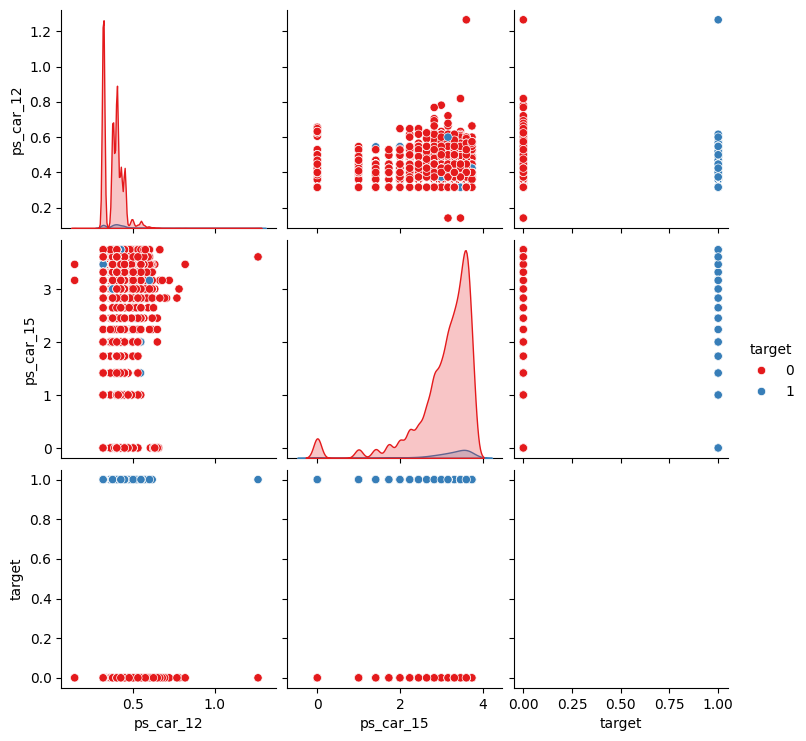

In [14]:
sample = trainset.sample(frac=0.05)
var = ['ps_car_12', 'ps_car_15', 'target']
sample = sample[var]
sns.pairplot(sample, vars=var, hue='target', palette='Set1', diag_kind='kde')
plt.show()

### Calculated features

The features **ps_calc_01, ps_calc_02** and **ps_calc_03** have very similar distributions and could be some kind of ratio, since the maximum value is for all three 0.9. The other calculated values have maximum value an integer value (5, 6, 7, 10, 12).

Let's visualize the real features distribution using density plot.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\4000833161.py:13: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t1[feature], bw=0.5, label='target = 1')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\4000833161.py:14: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t0[feature], bw=0.5, label='target = 0')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\4000833161.py:13: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

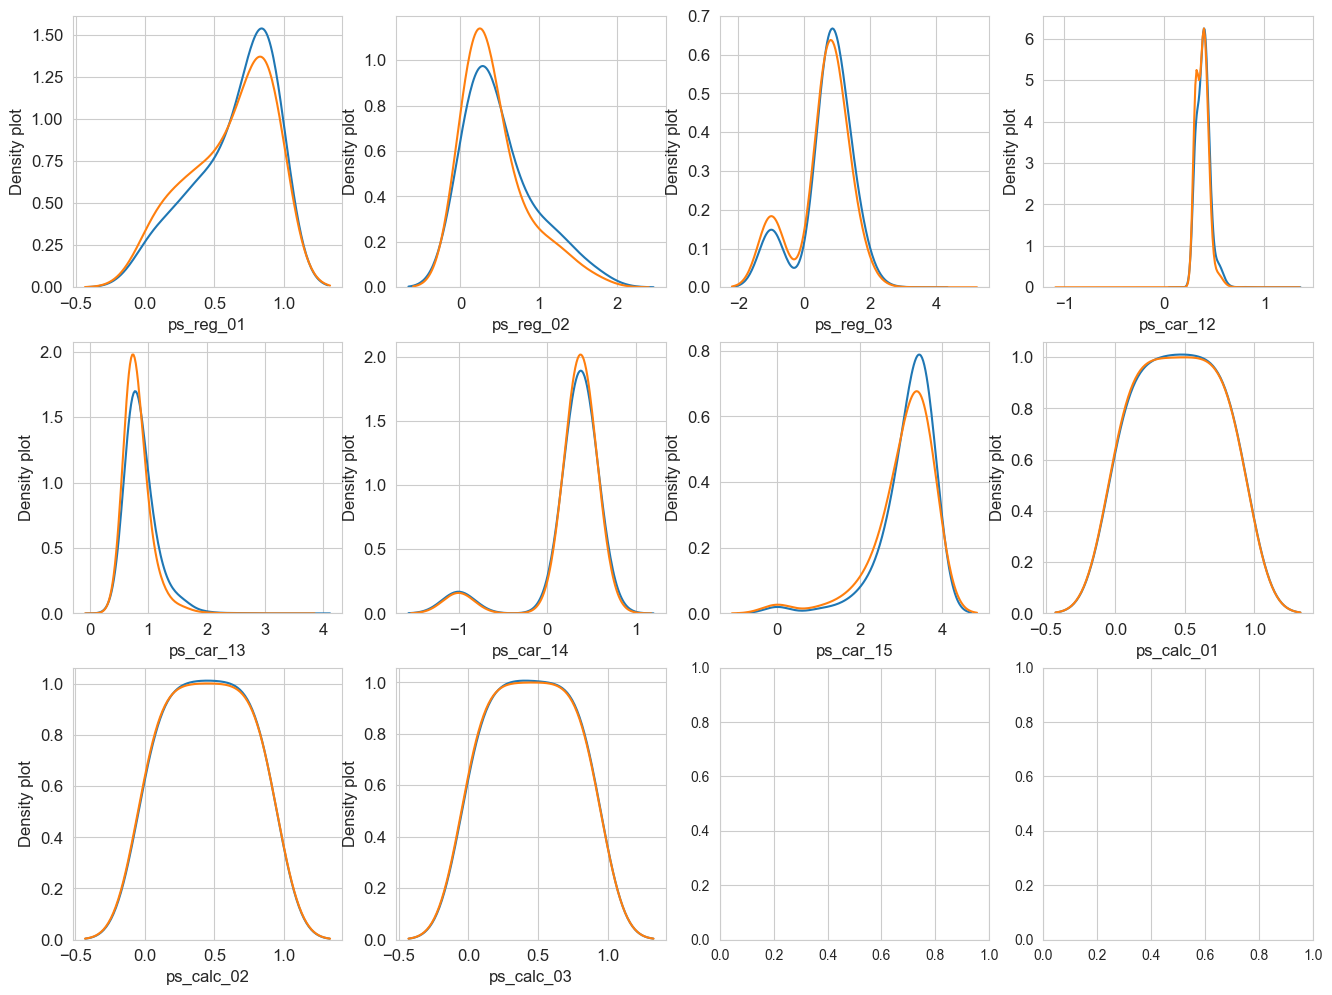

In [15]:
var = metadata[(metadata.type=='real') & (metadata.preserve)].index
i = 0
t1 = trainset.loc[trainset['target'] != 0]
t0 = trainset.loc[trainset['target'] == 0]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(3, 4, figsize=(16, 12))

for feature in var:
    i += 1
    plt.subplot(3, 4, i)
    sns.kdeplot(t1[feature], bw=0.5, label='target = 1')
    sns.kdeplot(t0[feature], bw=0.5, label='target = 0')
    plt.ylabel('Density plot', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

**ps_reg_02, ps_car_13, ps_car_15** shows the most different distributions between sets of values associated with target=0 and target=1.

Let's visualize the correlation between the real features

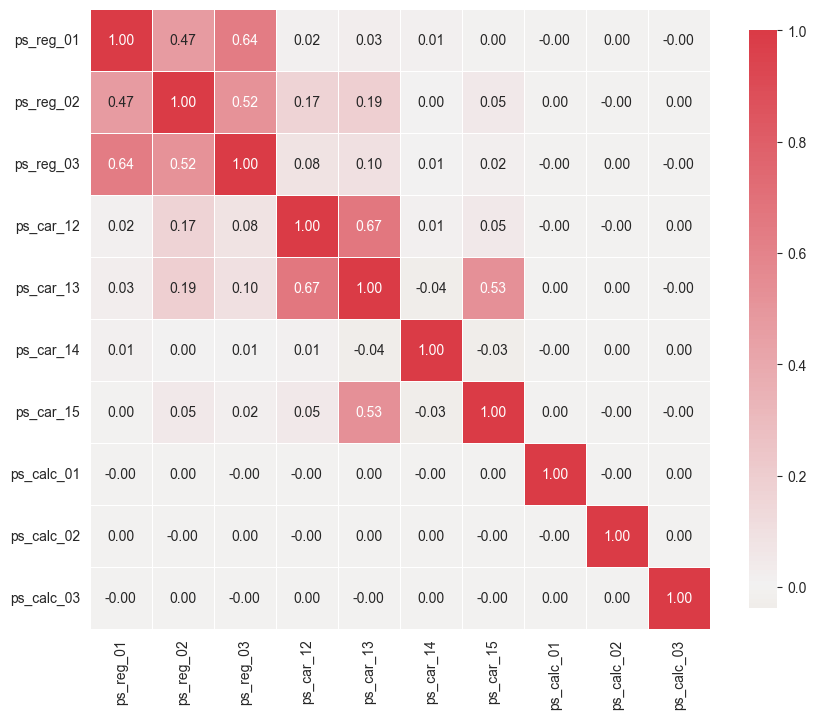

In [16]:
def corr_heatmap(var):
    correlations = trainset[var].corr()

    cmap = sns.diverging_palette(50, 10, as_cmap=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(correlations, cmap=cmap, vmax=1.0, center=0, fmt='.2f', square=True, linewidths=.5, annot=True, cbar_kws={'shrink':.75})
    plt.show();

var = metadata[(metadata.type == 'real') & (metadata.preserve)].index
corr_heatmap(var)

Let's visualize the plots of the variables with strong correlations. These are:

* ps_reg_01 with ps_reg_02 (0.47);
* ps_reg_01 with ps_reg_03 (0.64);
* ps_reg_02 with ps_reg_03 (0.52);
* ps_car_12 with ps_car_13 (0.67);
* ps_car_13 with ps_car_15 (0.53);

To show the pairs of values that are correlated we use *pairplot*. Before representing the pairs, we subsample the data, using only 2% in the sample.

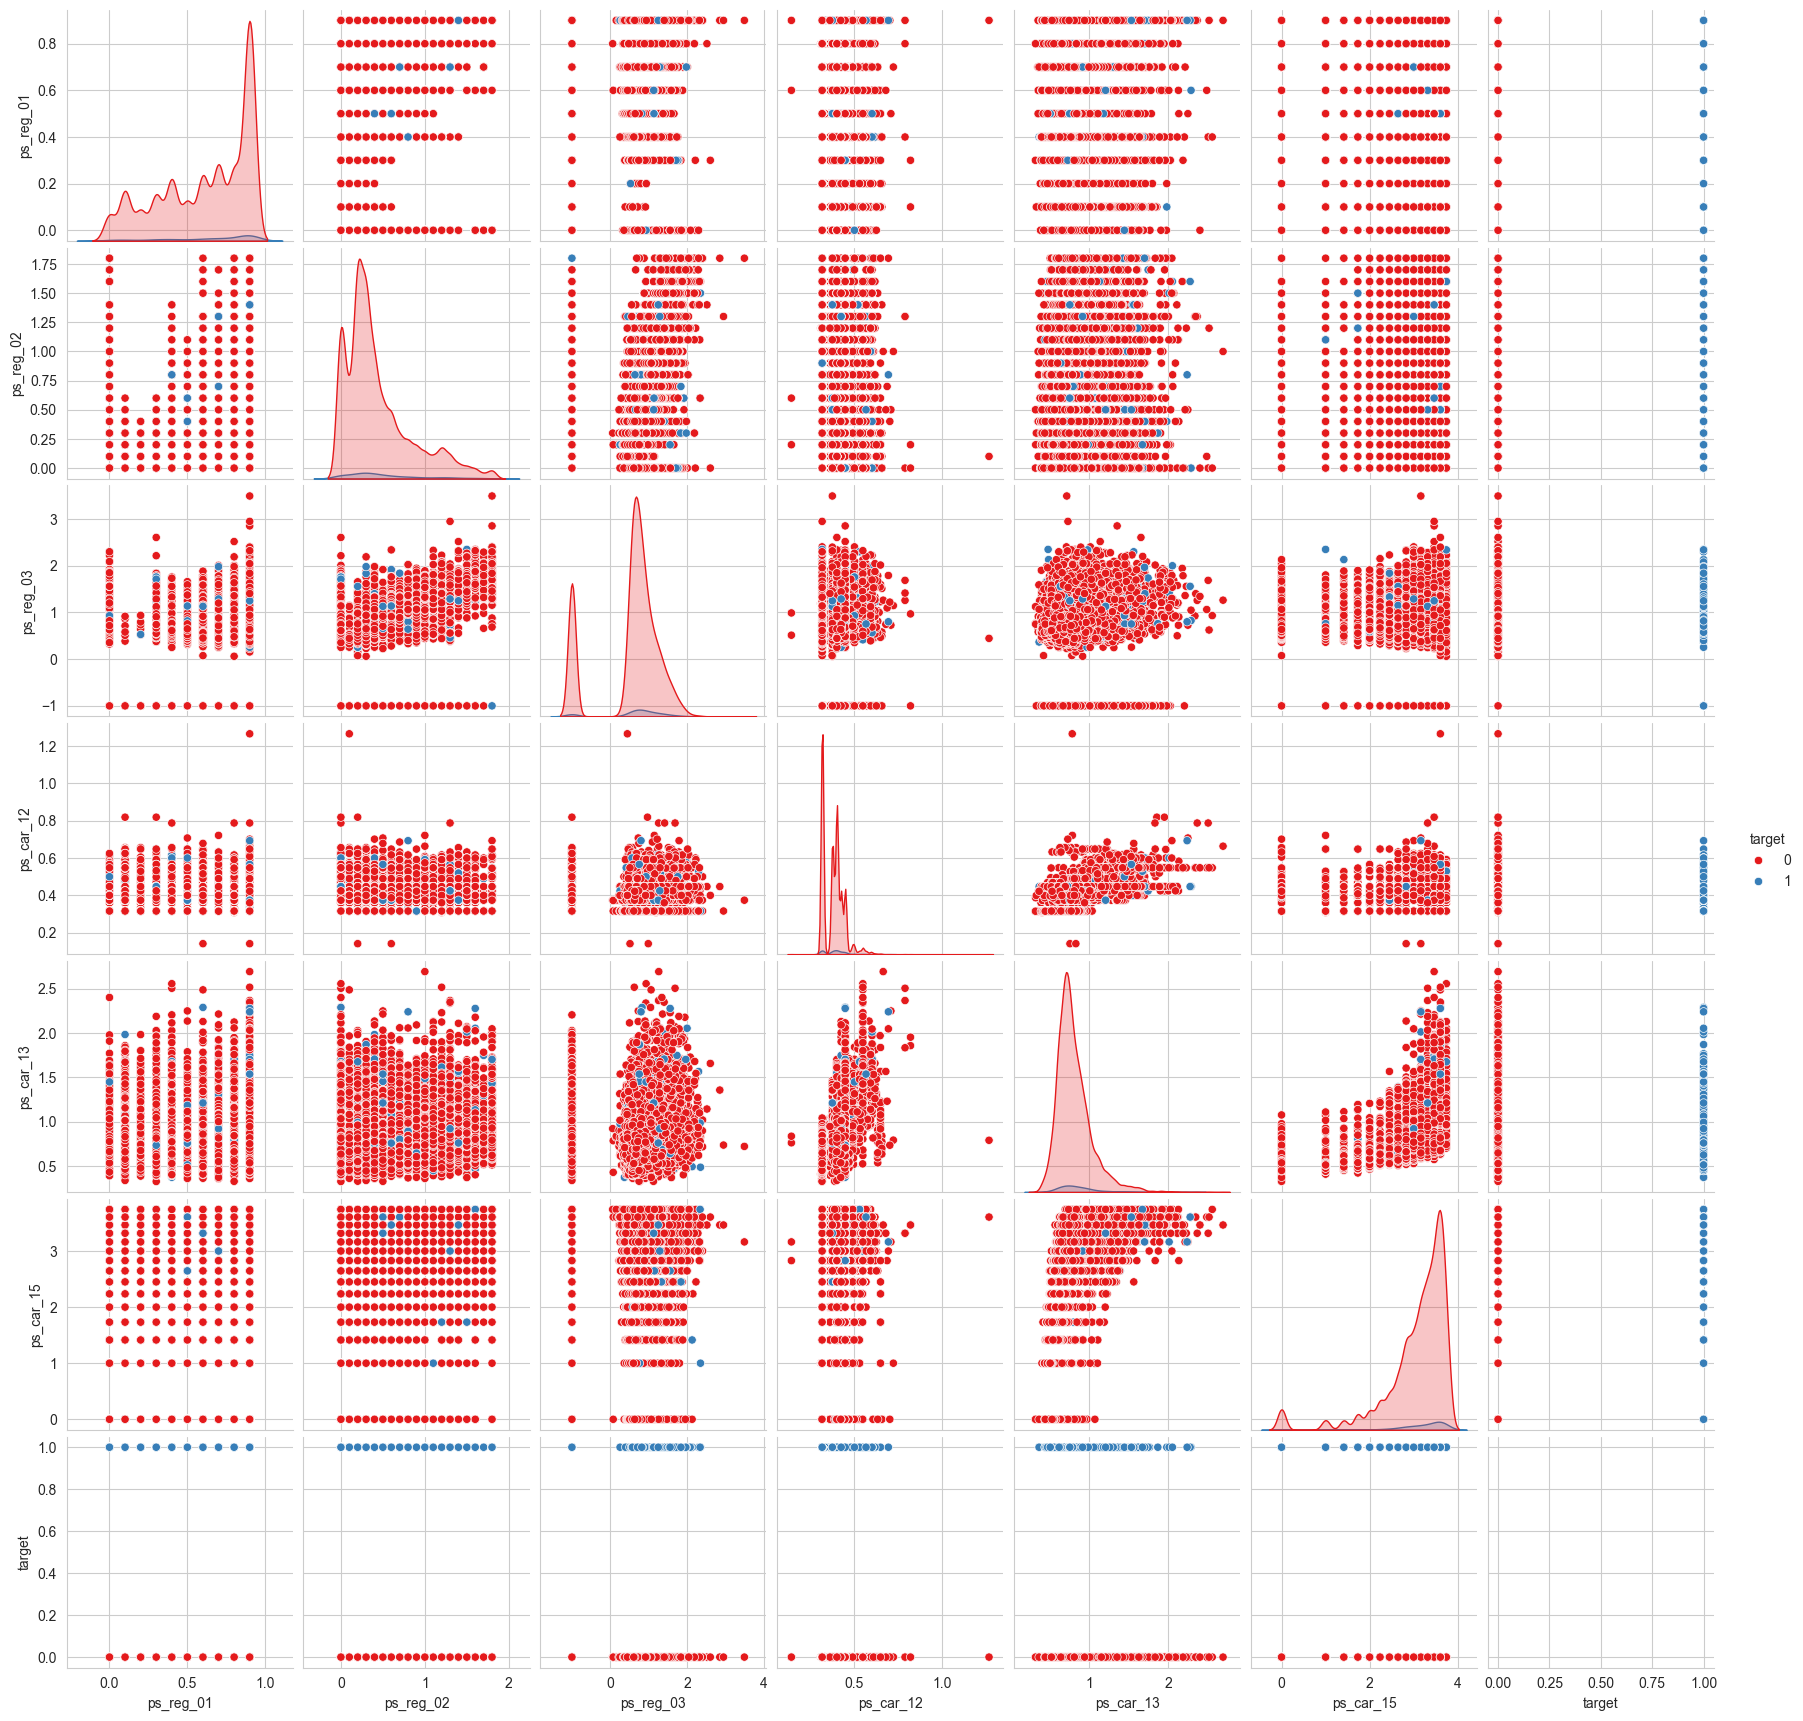

In [17]:
sample = trainset.sample(frac=0.05)
var = ['ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_15', 'target']
sample = sample[var]
sns.pairplot(sample, vars=var, hue='target', palette='Set1', diag_kind='kde')
plt.show()

## Binary features

In [18]:
v = metadata[(metadata.type == 'binary') & (metadata.preserve)].index
trainset[v].describe()

,target,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.036448,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.660823,0.121081,0.153446,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,0.187401,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.473430,0.326222,0.360417,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Let's plot the distribution of the binary data in the training dataset. With blue we represent the percent of 0 and with red the percent of 1.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2172144401.py:17: UserWarning: Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend((p1, p2), ('Zero', 'One'))


<Figure size 640x480 with 0 Axes>

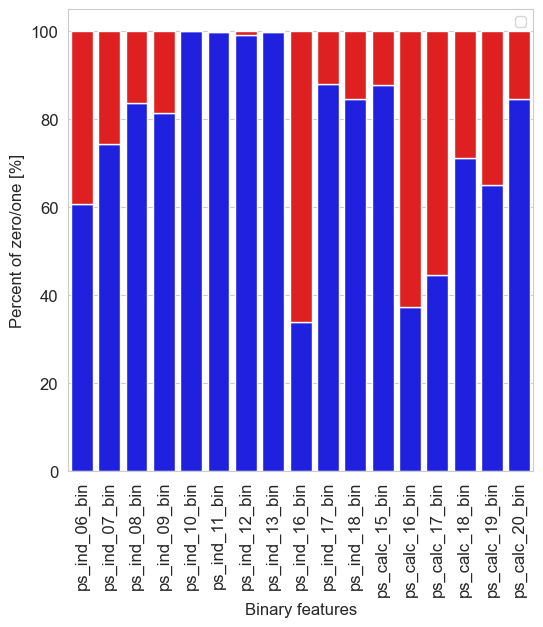

In [19]:
bin_col = [col for col in trainset.columns if '_bin' in col]
zero_list = []
one_list = []
for col in bin_col:
    zero_list.append((trainset[col]==0).sum()/trainset.shape[0]*100)
    one_list.append((trainset[col]==1).sum()/trainset.shape[0]*100)
plt.figure()
fig, ax = plt.subplots(figsize=(6, 6))

p1 = sns.barplot(ax=ax, x=bin_col, y=zero_list, color='blue')
p2 = sns.barplot(ax=ax, x=bin_col, y=one_list, bottom=zero_list, color='red')
plt.ylabel('Percent of zero/one [%]', fontsize=12)
plt.xlabel('Binary features', fontsize=12)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend((p1, p2), ('Zero', 'One'))
plt.show()

**ps_ind_10_bin, ps_ind_11_bin, ps_ind_12_bin** and **ps_ind_13_bin** have very small number of values 1 (less than 0.5%) whilst the number of value 1 is very large for **ps_ind_16_bin** and **ps_calc_16_bin** (more than 60%).

:et's see now the distribution of binary data and the corresponding values of **target** variable.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\3685494053.py:14: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t1[feature], bw=0.5, label='target = 1')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\3685494053.py:15: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(t0[feature], bw=0.5, label='target = 0')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\3685494053.py:14: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

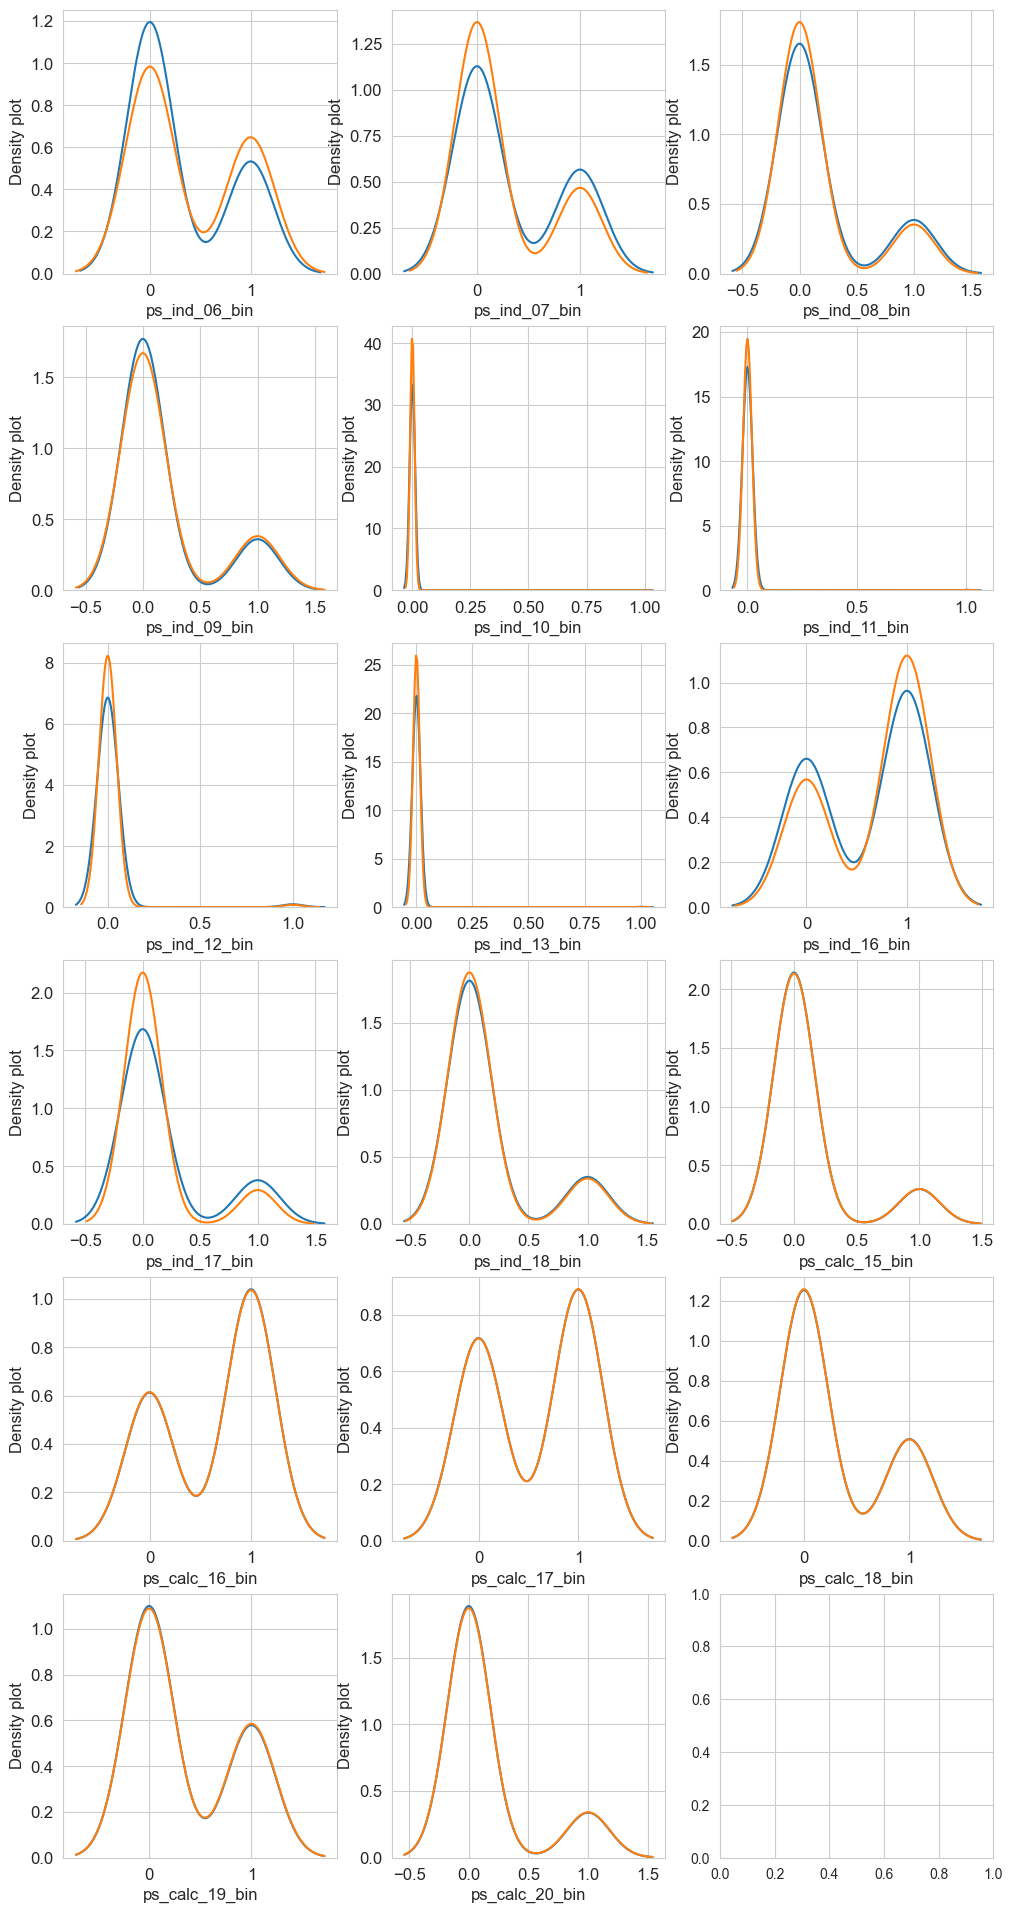

In [20]:
var = metadata[(metadata.type=='binary') & (metadata.preserve)].index
var = [col for col in trainset.columns if '_bin' in col]
i = 0
t1 = trainset.loc[trainset['target'] != 0]
t0 = trainset.loc[trainset['target'] == 0]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(6, 3, figsize=(12, 24))

for feature in var:
    i += 1
    plt.subplot(6, 3, i)
    sns.kdeplot(t1[feature], bw=0.5, label='target = 1')
    sns.kdeplot(t0[feature], bw=0.5, label='target = 0')
    plt.ylabel('Density plot', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

**ps_ind_06_bin, ps_ind_07_bin, ps_ind_16_bin, ps_ind_17_bin** shows high imbalance between distribution of values of 1 and 0 for values of target equals with 1 and 0, **ps_ind_08_bin** shows a small imbalance while the other features are well balanced, having similar density plots.

## Categorical features

We will represent the distribution on categorical data in two ways. First, we calculate the percentage of target=1 per category value and represent these percentages using bar plots.

AttributeError: 'Text' object has no property 'fontsie'

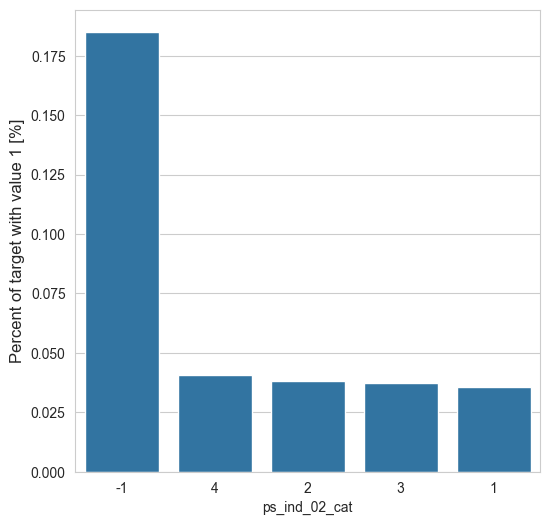

In [21]:
var = metadata[(metadata.type == 'categorical') & (metadata.preserve)].index

for feature in var:
    fig, ax = plt.subplots(figsize=(6, 6))

    cat_perc = trainset[[feature, 'target']].groupby([feature], as_index=False).mean()
    cat_perc.sort_values(by='target', ascending=False, inplace=True)

    sns.barplot(ax=ax, x=feature, y='target', data=cat_perc, order=cat_perc[feature])
    plt.ylabel('Percent of target with value 1 [%]', fontsize=12)
    plt.xlabel(feature, fontsie=12)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.show()

Alternatively we represent the categorical features using density plot. We select values with target=0 and target=1 and represent both density plots on the same graphic.

In [ ]:
var = metadata[(metadata.type=='categorical') & (metadata.preserve)].index
i = 0
t1 = trainset.loc[trainset['target'] != 0]
t0 = trainset.loc[trainset['target'] == 0]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(4, 4, figsize=(16, 16))

for feature in var:
    i += 1
    plt.subplot(4, 4, i)
    sns.kdeplot(t1[feature], bw=0.5, label='target = 1')
    sns.kdeplot(t0[feature], bw=0.5, label='target = 0')
    plt.ylabel('Density plot', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

**ps_car_03_cat, ps_car_05_cat** shows the most different density plot between values associated with target=0 and target=1.

## Data unbalance between train and test data

Let's compare the distribution of the features in the train and test datasets.

We start with the reg or registration feataures.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1493240140.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(trainset[feature], bw=0.5, label='train')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1493240140.py:12: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(testset[feature], bw=0.5, label='test')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1493240140.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

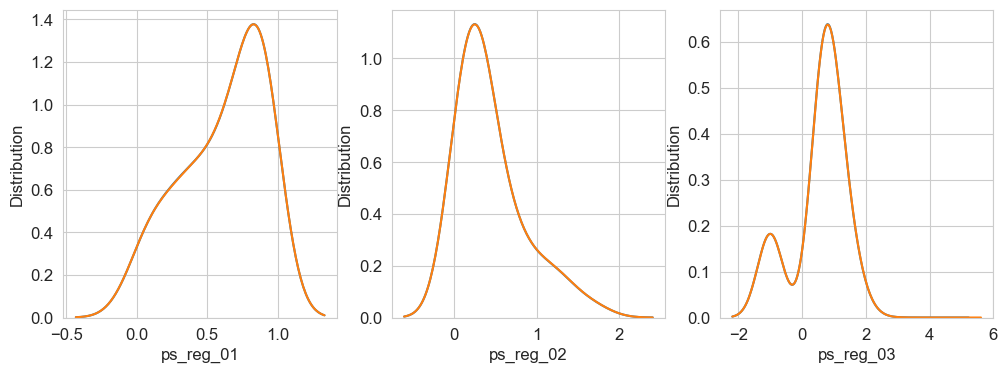

In [22]:
var = metadata[(metadata.category=='registration') & (metadata.preserve)].index

sns.set_style('whitegrid')

plt.figure()
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i = 0
for feature in var:
    i = i + 1
    plt.subplot(1, 3, i)
    sns.kdeplot(trainset[feature], bw=0.5, label='train')
    sns.kdeplot(testset[feature], bw=0.5, label='test')
    plt.ylabel('Distribution', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()

    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

All reg features shows well balanced train and test sets.

Let's continue with car features.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2106196192.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(trainset[feature], bw=0.5, label='train')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2106196192.py:12: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(testset[feature], bw=0.5, label='test')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2106196192.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

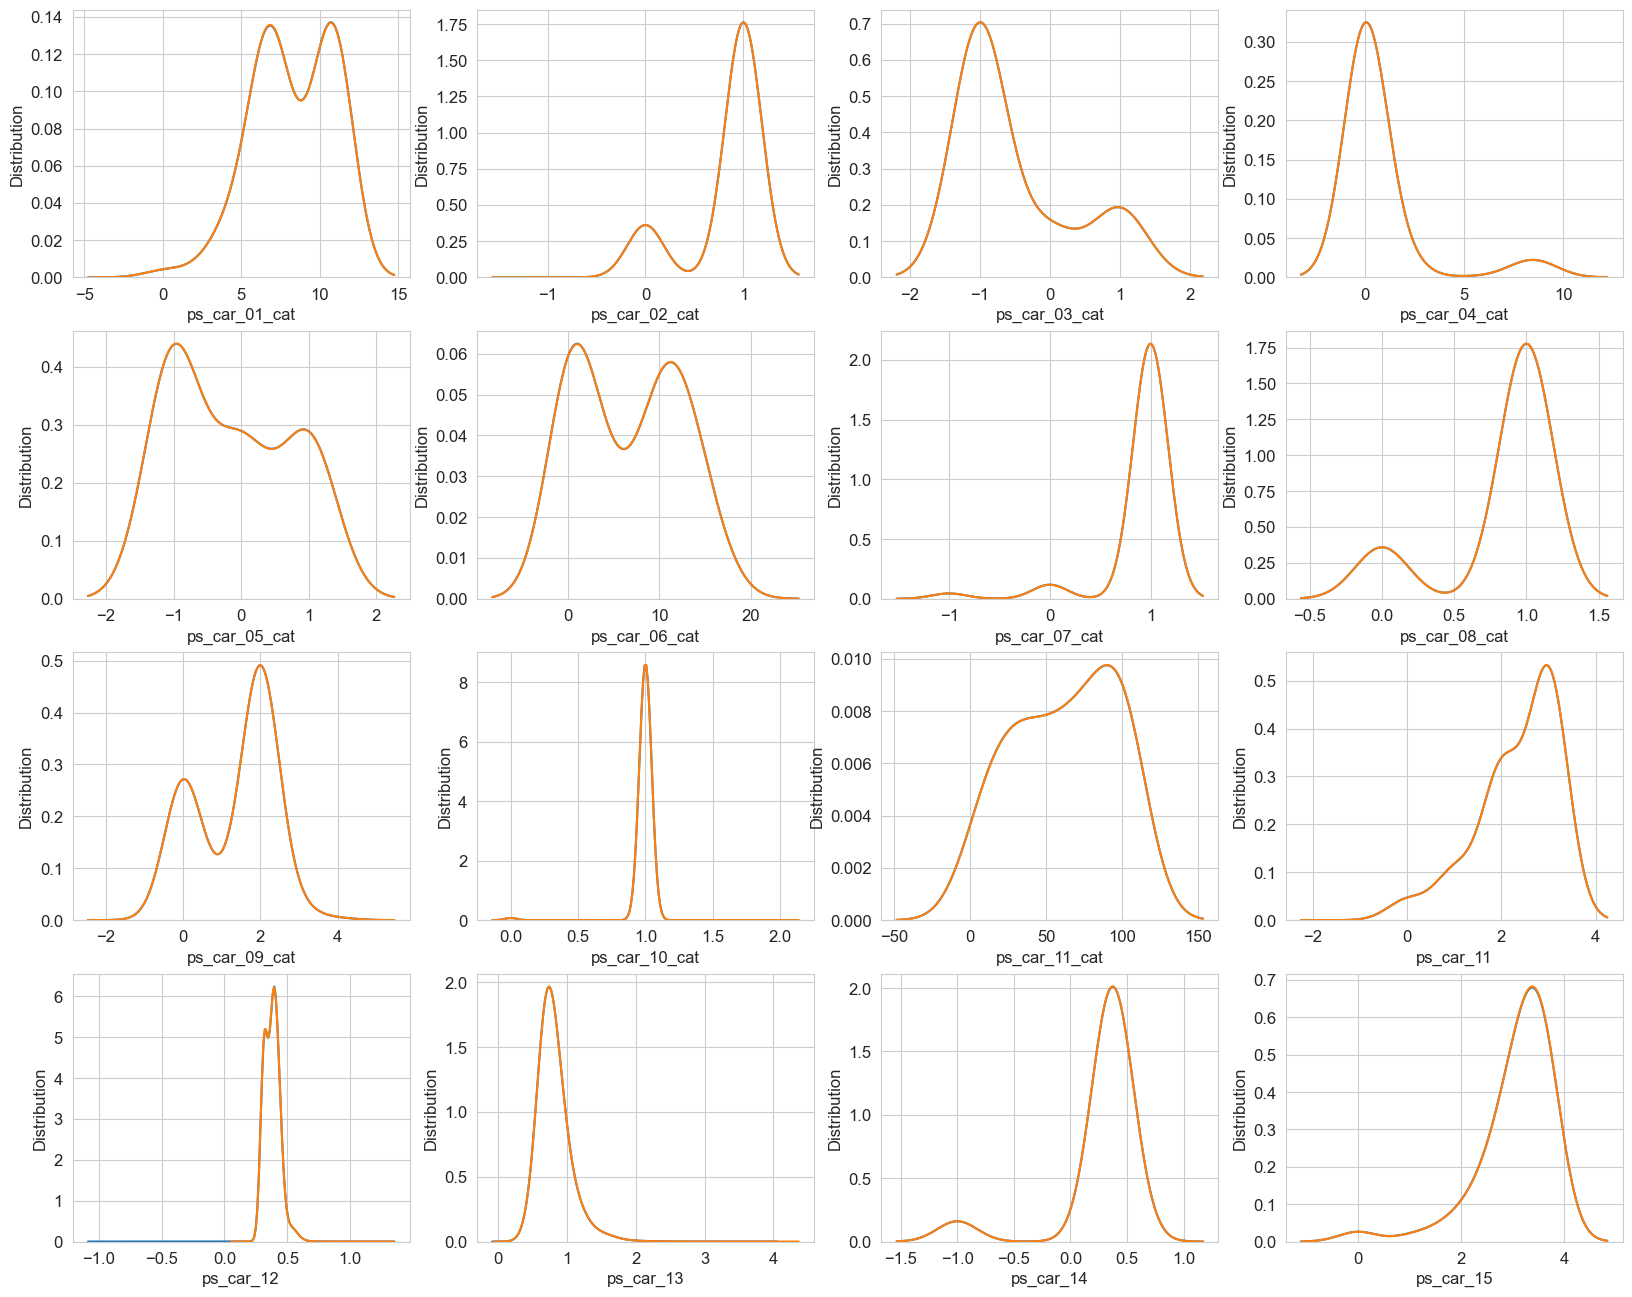

In [23]:
var = metadata[(metadata.category=='car') & (metadata.preserve)].index

sns.set_style('whitegrid')

plt.figure()
fig, ax = plt.subplots(4, 4, figsize=(20, 16))
i = 0
for feature in var:
    i = i + 1
    plt.subplot(4, 4, i)
    sns.kdeplot(trainset[feature], bw=0.5, label='train')
    sns.kdeplot(testset[feature], bw=0.5, label='test')
    plt.ylabel('Distribution', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()

    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

From the car features, all variables looks well balanced between train and test set.

Let's look now to the ind (individual) values.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2424586374.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(trainset[feature], bw=0.5, label='train')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2424586374.py:12: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(testset[feature], bw=0.5, label='test')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\2424586374.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

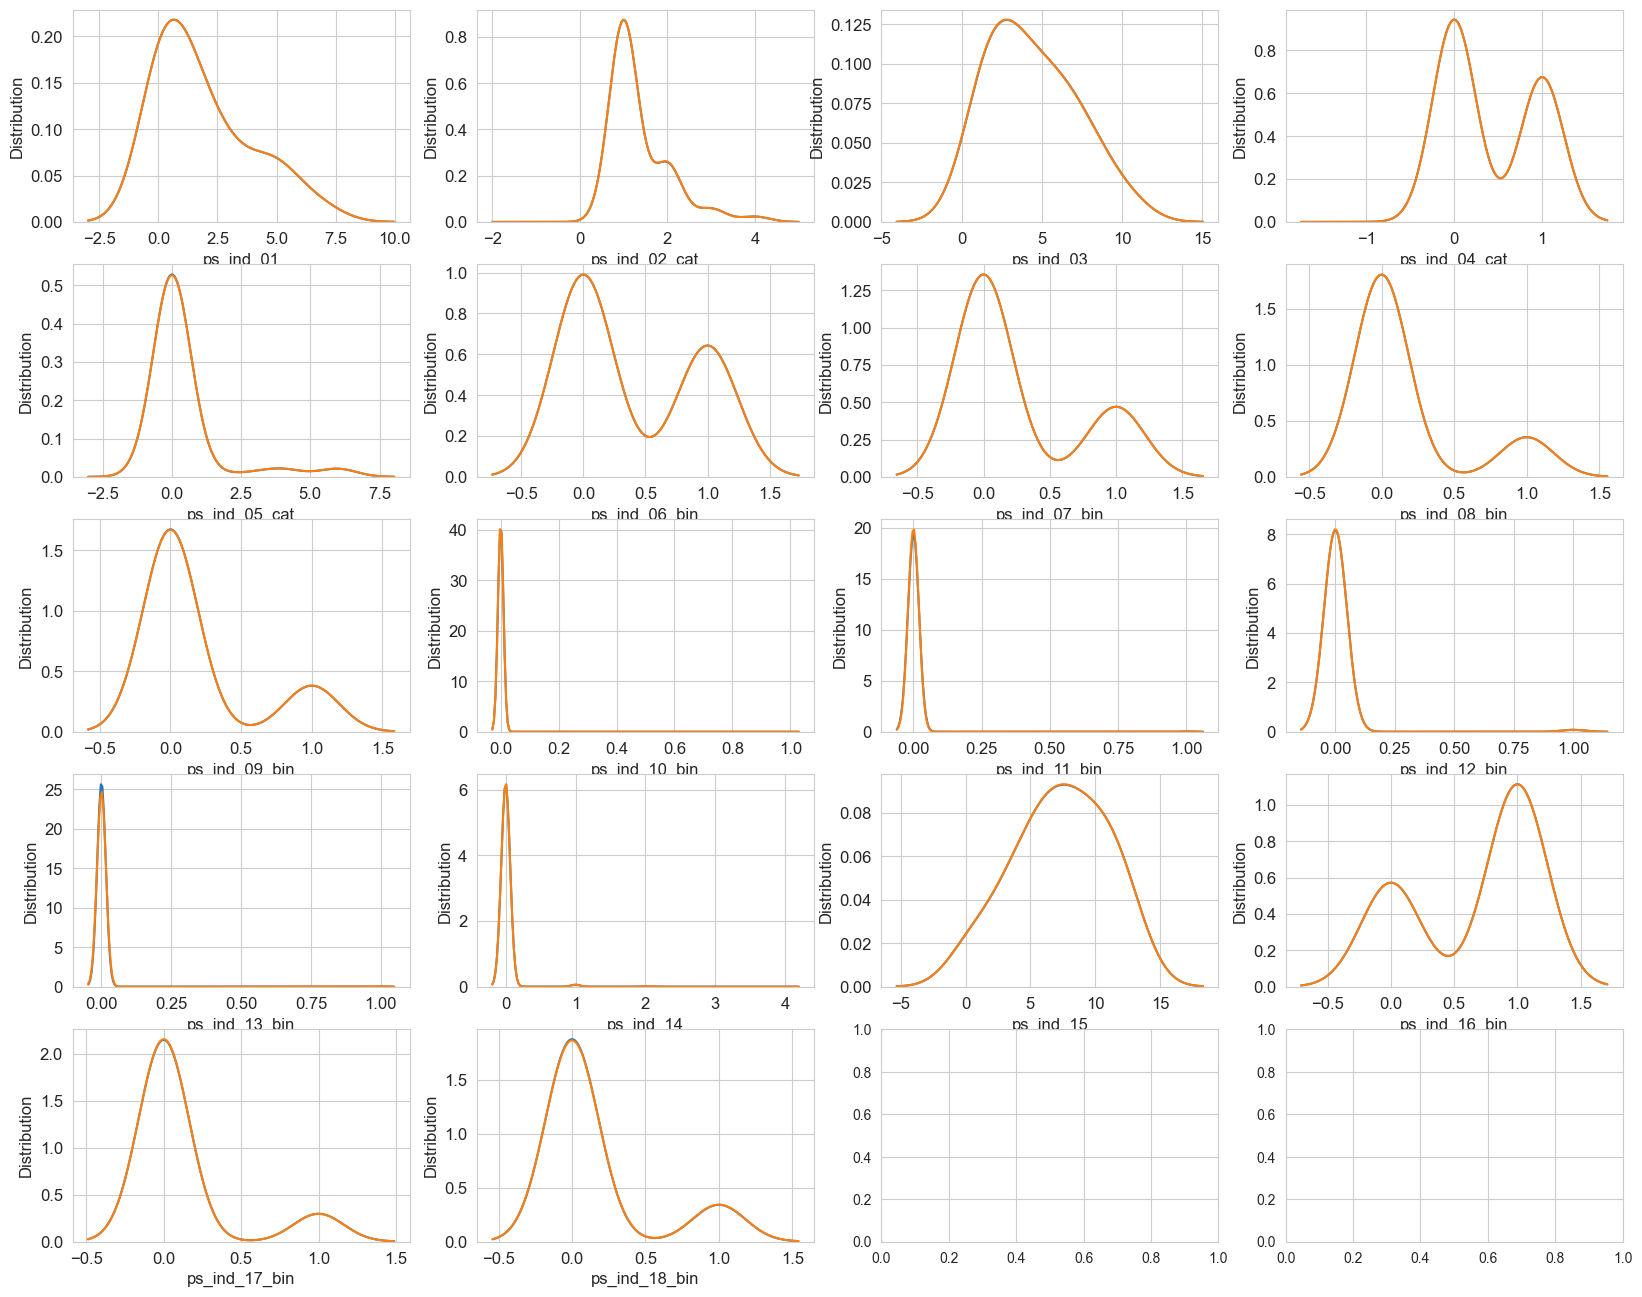

In [26]:
var = metadata[(metadata.category=='individual') & (metadata.preserve)].index

sns.set_style('whitegrid')

plt.figure()
fig, ax = plt.subplots(5, 4, figsize=(20, 16))
i = 0
for feature in var:
    i = i + 1
    plt.subplot(5, 4, i)
    sns.kdeplot(trainset[feature], bw=0.5, label='train')
    sns.kdeplot(testset[feature], bw=0.5, label='test')
    plt.ylabel('Distribution', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()

    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

All ind features are well balanced between train and test sets.

Let's check now calc features.

C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1985812905.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(trainset[feature], bw=0.5, label='train')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1985812905.py:12: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(testset[feature], bw=0.5, label='test')
C:\Users\USER\AppData\Local\Temp\ipykernel_16144\1985812905.py:11: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.5`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.


<Figure size 640x480 with 0 Axes>

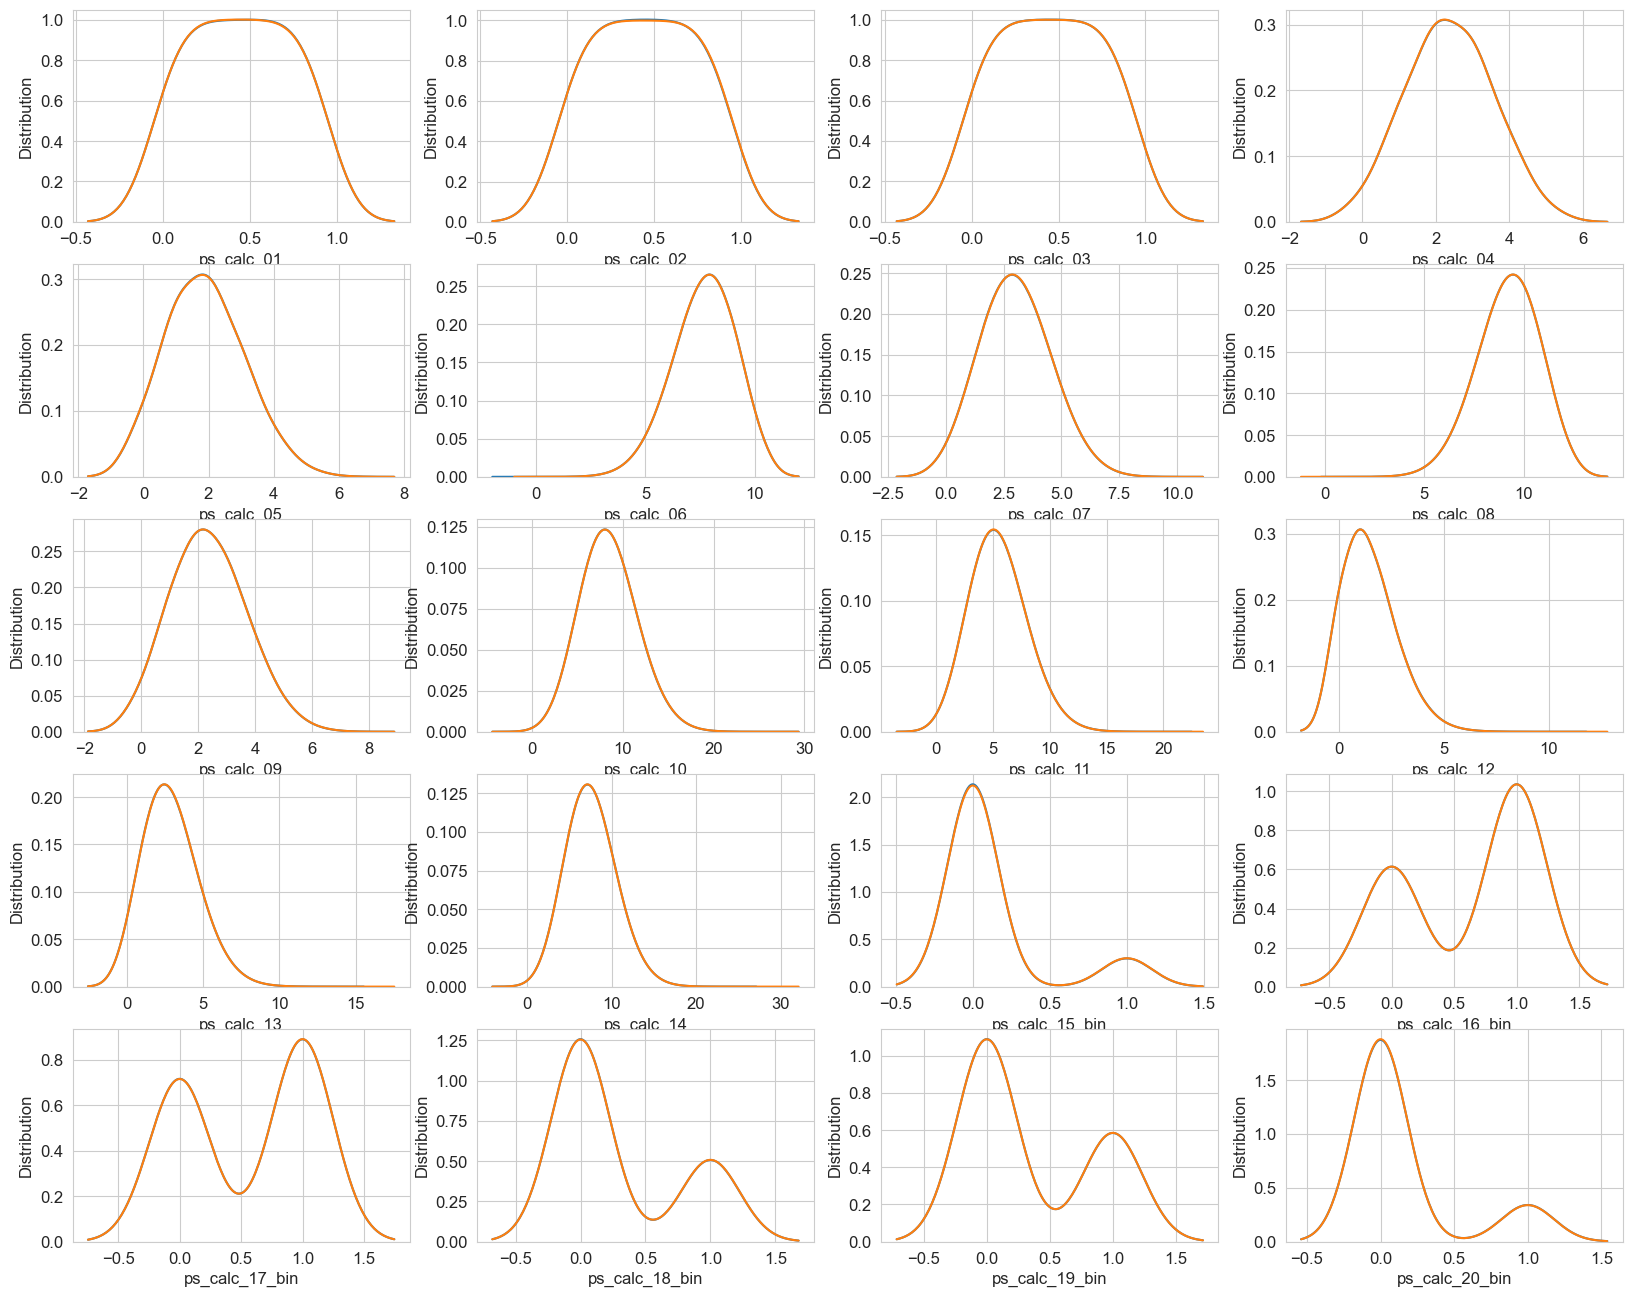

In [27]:
var = metadata[(metadata.category=='calculated') & (metadata.preserve)].index

sns.set_style('whitegrid')

plt.figure()
fig, ax = plt.subplots(5, 4, figsize=(20, 16))
i = 0
for feature in var:
    i = i + 1
    plt.subplot(5, 4, i)
    sns.kdeplot(trainset[feature], bw=0.5, label='train')
    sns.kdeplot(testset[feature], bw=0.5, label='test')
    plt.ylabel('Distribution', fontsize=12)
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

All calc features are well balanced between train and test sets.

In reference [5] it is also noticed the well balancing between train and test sets. It is also suggested that calc features might be all engineered and actually not relevant. This can only be assessed by careful successive elimination using CV score using one or more predictive models.

# Check data quality

Let's inspect the features with missing values:

In [28]:
vars_with_missing = []

for feature in trainset.columns:
    missings = trainset[trainset[feature] == -1][feature].count()
    if missings > 0:
        vars_with_missing.append(feature)
        missings_perc = missings/trainset.shape[0]

        print('Variable {} has {} records ({:.2%}) with missing values'.format(feature, missings, missings_perc))

print('In total, there are {} variables with missing values'.format(len(vars_with_missing)))

Variable ps_ind_02_cat has 216 records (0.04%) with missing values
Variable ps_ind_04_cat has 83 records (0.01%) with missing values
Variable ps_ind_05_cat has 5809 records (0.98%) with missing values
Variable ps_reg_03 has 107772 records (18.11%) with missing values
Variable ps_car_01_cat has 107 records (0.02%) with missing values
Variable ps_car_02_cat has 5 records (0.00%) with missing values
Variable ps_car_03_cat has 411231 records (69.09%) with missing values
Variable ps_car_05_cat has 266551 records (44.78%) with missing values
Variable ps_car_07_cat has 11489 records (1.93%) with missing values
Variable ps_car_09_cat has 569 records (0.10%) with missing values
Variable ps_car_11 has 5 records (0.00%) with missing values
Variable ps_car_12 has 1 records (0.00%) with missing values
Variable ps_car_14 has 42620 records (7.16%) with missing values
In total, there are 13 variables with missing values


# Prepare the data for model

### Drop **calc** columns

We also drop the **calc** columns, as recommended in [5]. These seems to be all engineered and, according to Dmitry Altukhov, he was able to improve his CV score while successively removing all of them.

In [29]:
col_to_drop = trainset.columns[trainset.columns.str.startswith('ps_calc_')]
trainset = trainset.drop(col_to_drop, axis=1)
testset = testset.drop(col_to_drop, axis=1)

### Drop variables with too many missing values

We select from the variables with missing values two, **ps_car_03_cat** and **ps_car_05_cat** to drop.

In [30]:
vars_to_drop = ['ps_car_03_cat', 'ps_car_05_cat']
trainset.drop(vars_to_drop, inplace=True, axis=1)
testset.drop(vars_to_drop, inplace=True, axis=1)
metadata.loc[(vars_to_drop), 'keep'] = False

In [31]:
def add_noise(series, noise_level):
    return series * (1 + noise_level * np.random.randn(len(series)))

def target_encode(trn_series=None,
                  tst_series=None,
                  target=None,
                  min_samples_leaf=1,
                  smoothing=1,
                  noise_level=0):
    assert len(trn_series) == len(target)
    assert trn_series.name == tst_series.name
    temp = pd.concat([trn_series, target], axis=1)

    averages = temp.groupby(by=trn_series.name)[target.name].agg(['mean', 'count'])

    smoothing =1 / (1 + np.exp(-(averages['count'] - min_samples_leaf) / smoothing))

    prior = target.mean()

    averages[target.name] = prior * (1 - smoothing) + averages['mean'] * smoothing
    averages.drop(['mean', 'count'], axis=1, inplace=True)
    
    ft_trn_series = pd.merge(
        trn_series.to_frame(trn_series.name),
        averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
        on=tst_series.name,
        how='left'
    )['average'].rename(trn_series.name + '_mean').fillna(prior)
    ft_trn_series.index = trn_series.index
    ft_tst_series = pd.merge(
        tst_series.to_frame(tst_series.name),
        averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
        on=tst_series.name,
        how='left'
    )['average'].rename(trn_series.name + '_mean').fillna(prior)

    ft_tst_series.index = tst_series.index
    return add_noise(ft_trn_series, noise_level), add_noise(ft_tst_series, noise_level)

### Replace ps_car_11_cat with encoded value

Using the **target_encode** function, we replace the **ps_car_11_cat** with an encoded value in both **train** and **test** datasets.

In [32]:
train_encoded, test_encoded = target_encode(trainset['ps_car_11_cat'],
                                           testset['ps_car_11_cat'],
                                           target=trainset.target,
                                           min_samples_leaf=100,
                                           smoothing=10,
                                           noise_level=0.01)

trainset['ps_car_11_cat_te'] = train_encoded
trainset.drop('ps_car_11_cat', axis=1, inplace=True)
metadata.loc['ps_car_11_cat', 'keep'] = False
testset['ps_car_11_cat_te'] = test_encoded
testset.drop('ps_car_11_cat', axis=1, inplace=True)

### Balance target variable

The target variable is highly unbalanced. This can be improved by either undersampling values with **target = 0** or oversampling values with **target = 1**. Because there is a rather large training set, we opt for the **undersampling**.

In [34]:
desired_apriori = 0.10

idx_0 = trainset[trainset.target==0].index
idx_1 = trainset[trainset.target==1].index

nb_0 = len(trainset.loc[idx_0])
nb_1 = len(trainset.loc[idx_1])

undersampling_rate = ((1-desired_apriori) * nb_1) / (nb_0 * desired_apriori)
undersampled_nb_0 = int(undersampling_rate * nb_0)
print('Rate to undersample records with target=0: {}'.format(undersampling_rate))
print('Number of records with target=0 after undersampling: {}'.format(undersampled_nb_0))

undersampled_idx = shuffle(idx_0, random_state=314, n_samples=undersampled_nb_0)

idx_list = list(undersampled_idx) + list(idx_1)

trainset = trainset.loc[idx_list].reset_index(drop=True)

Rate to undersample records with target=0: 0.34043569687437886
Number of records with target=0 after undersampling: 195246


### Replace -1 values with NaN

Most of the classifiers we would use have pretty good strategies to manage missing (or NaN) values.

In [35]:
trainset = trainset.replace(-1, np.nan)
testset = testset.replace(-1, np.nan)

### Dummify **cat** values

We will create dummy variables for the **categorical (cat)** features

In [36]:
cat_features = [a for a in trainset.columns if a.endswith('cat')]

for column in cat_features:
    temp = pd.get_dummies(pd.Series(trainset[column]))
    trainset = pd.concat([trainset, temp], axis=1)
    trainset = trainset.drop([column], axis=1)

for column in cat_features:
    temp = pd.get_dummies(pd.Series(testset[column]))
    testset = pd.concat([testset, temp], axis=1)
    testset = testset.drop([column], axis=1)

### Drop unused and **target** columns

We separate the **id** and **target** (drop these columns)

In [37]:
id_test = testset['id'].values
target_train = trainset['target'].values

trainset = trainset.drop(['target', 'id'], axis=1)
testset = testset.drop(['id'], axis=1)

Let's inspect the training and test sets:

In [ ]:
print('Train dataset (rows, cols):', trainset.values.shape, '\nTest dataset (rows, cols):', testset.values.shape)

# Prepare the model

### Ensable class for cross validation and ensemble

Prepare an **Ensemble** class to split the data in KFolds, train the models and ensemble the results.

The class has an **init** method (called when an Ensemble objet is created) that accepts 4 parameters:

* **self** - the object to be initialized
* **n_splits** - the number of cross-validation splits to be used
* **stacker** - the model used for stacking the prediction results from the trained base models
* **base_models** - the list of base models used in training